Human Action Detection
Step 1:Import Libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [20]:
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split , GridSearchCV

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
import statsmodels.api as sm 

In [27]:
from sklearn.metrics import classification_report, r2_score

Step2: Data Importing & Analysis

In [32]:
df = pd.read_csv("mhealth_raw_data.csv")
df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.449020,-1.01030,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.449020,-1.01030,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.449020,-1.01030,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.456860,-1.00820,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.456860,-1.00820,0.025862,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215740,1.7849,-9.8287,0.29725,-0.341370,-0.90056,-0.61493,-3.7198,-8.9071,0.294230,0.041176,-0.99384,-0.480600,0,subject10
1215741,1.8687,-9.8766,0.46236,-0.341370,-0.90056,-0.61493,-3.7160,-8.7455,0.448140,0.041176,-0.99384,-0.480600,0,subject10
1215742,1.6928,-9.9290,0.16631,-0.341370,-0.90056,-0.61493,-3.8824,-9.1155,0.450480,0.041176,-0.99384,-0.480600,0,subject10
1215743,1.5279,-9.6306,0.30458,-0.341370,-0.90056,-0.61493,-3.5564,-9.1441,0.594880,0.041176,-0.99384,-0.480600,0,subject10


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  str    
dtypes: float64(12), int64(1), str(1)
memory usage: 129.9 MB


In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alx,1215745.0,1.494200,3.826485,-22.1460,0.14131,1.308900,2.575800,20.0540
aly,1215745.0,-9.692878,4.171303,-19.6190,-10.20100,-9.670300,-9.042200,21.1610
alz,1215745.0,-0.954806,5.461803,-19.3730,-2.64940,-0.016456,1.301300,25.0150
glx,1215745.0,-0.001599,0.491217,-2.1466,-0.43599,-0.014842,0.448980,60.4840
gly,1215745.0,-0.616632,0.354641,-7.7899,-0.81801,-0.707320,-0.540340,2.0113
glz,1215745.0,-0.158781,0.546798,-2.6267,-0.59332,-0.190570,0.322200,2.7701
arx,1215745.0,-3.713413,4.763586,-22.3610,-6.07600,-2.977600,-1.193700,19.8640
ary,1215745.0,-5.805526,5.757639,-18.9720,-9.40420,-7.461500,-2.533900,22.1910
arz,1215745.0,2.393880,3.876503,-18.2390,0.12965,1.928100,4.914700,25.7410
grx,1215745.0,-0.276106,0.527689,-8.3392,-0.70588,-0.354900,0.096078,3.3196


In [37]:
df.isnull().sum()

alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Activity'>

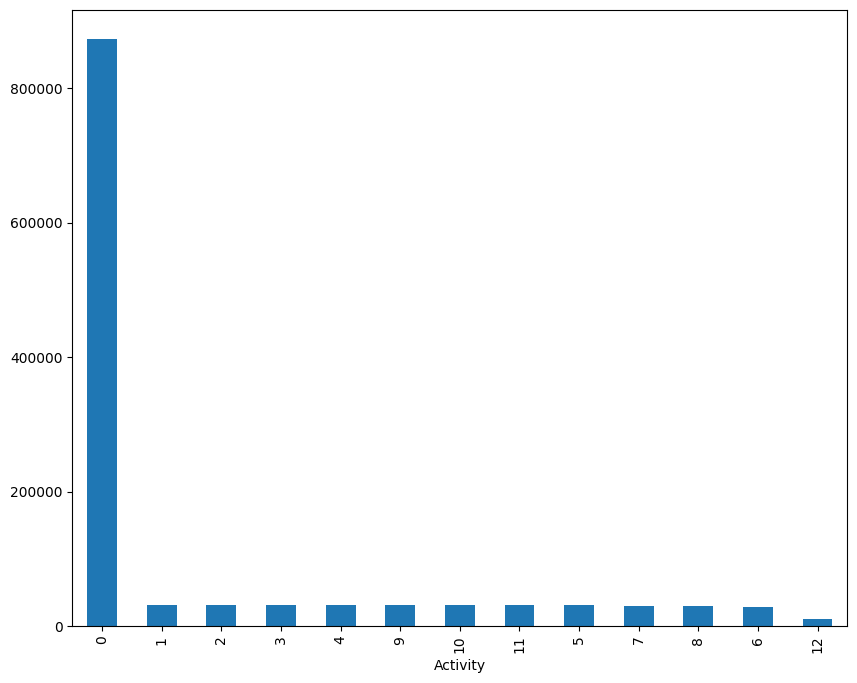

In [40]:
plt.figure(figsize=(10,8))
df['Activity'].value_counts().plot.bar()

In [41]:
data_activity_0 = df[df["Activity"] == 0]
data_activity_else = df[df["Activity"] != 0]

In [47]:
data_activity_0 = data_activity_0.sample(n=40000 , replace=True , random_state=42)
df = pd.concat([data_activity_0,data_activity_else])

<Axes: xlabel='Activity'>

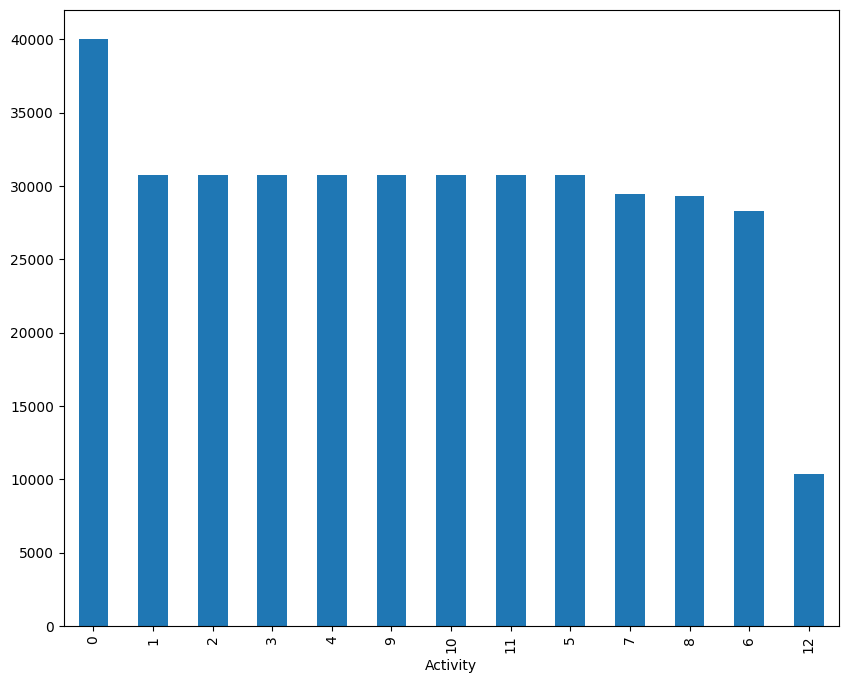

In [48]:
plt.figure(figsize=(10,8))
df['Activity'].value_counts().plot.bar()

In [49]:
len(df)

383195

Step 3: EDA

In [ ]:
activity_label = {
    0: "None",
    1: "Standing still (1 min)",
    2: " Sitting and relaxing (1 min)",
    3: "Lying down (1 min)",
    4: "Walking (1 min)",
    5: "Climbing stairs (1 min)",
    6: "Waist bends forward (20x)",
    7: "Frontal elevation of arms (20x)",
    8: "Knees bending (crouching) (20x)",
    9: "Cycling (1 min)",
    10: "Jogging (1 min)",
    11: "Running (1 min)",
    12: "Jump front & back (20x)",
}

=============================Standing still (1 min)-a============================


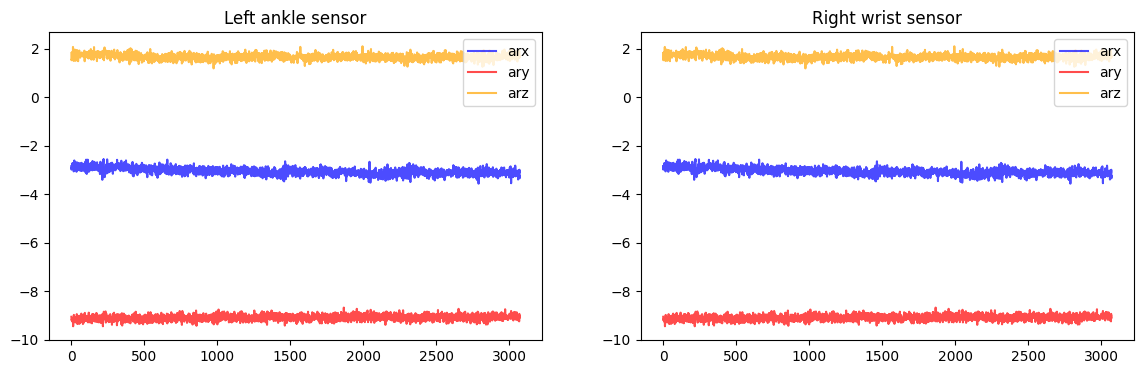

=============================Standing still (1 min)-g============================


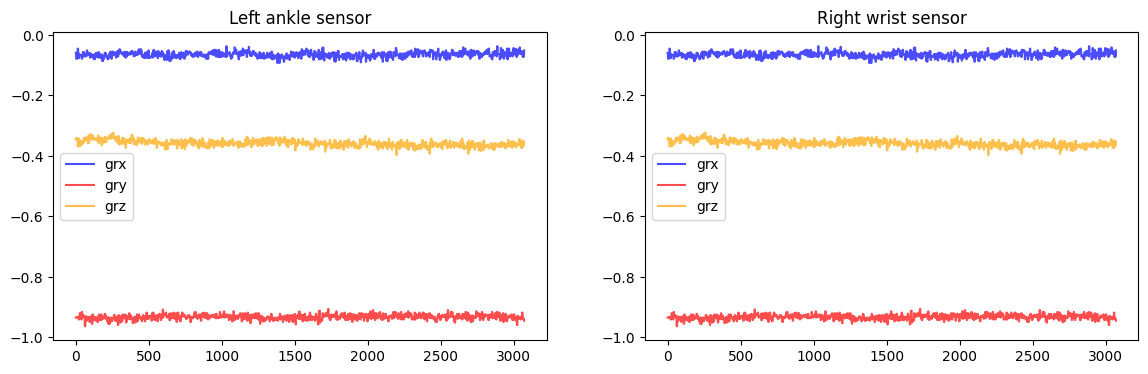

============================= Sitting and relaxing (1 min)-a============================


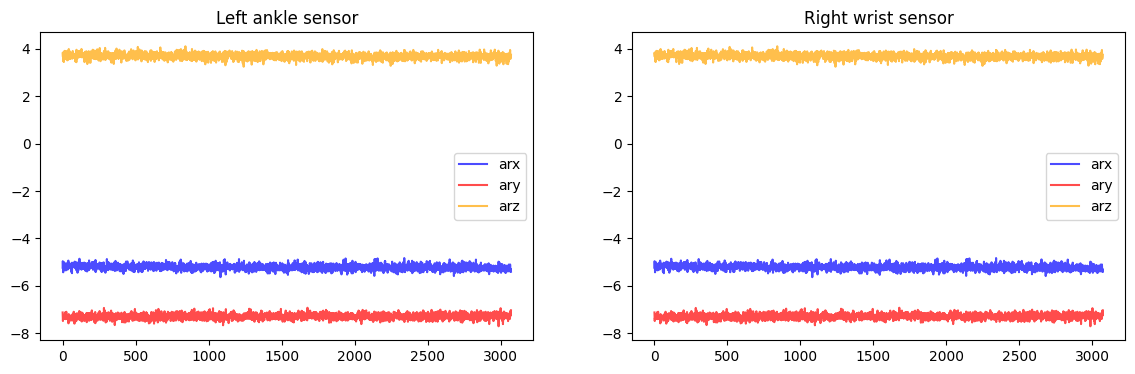

============================= Sitting and relaxing (1 min)-g============================


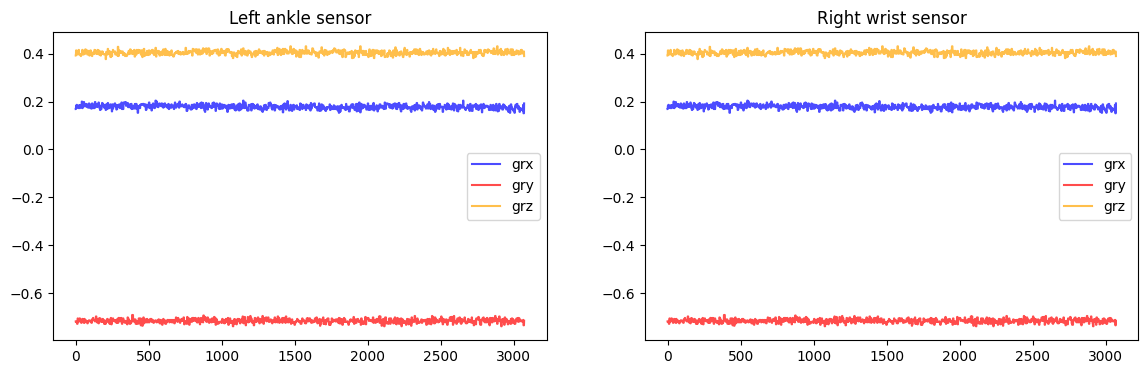

=============================Lying down (1 min)-a============================


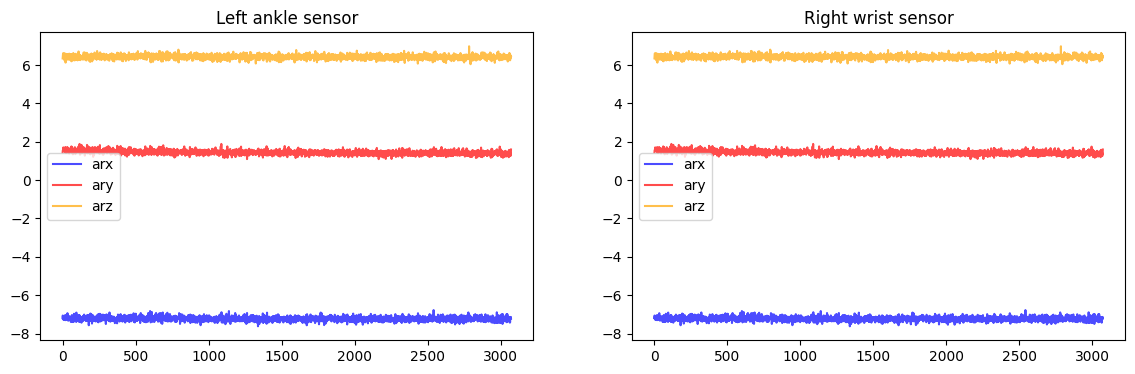

=============================Lying down (1 min)-g============================


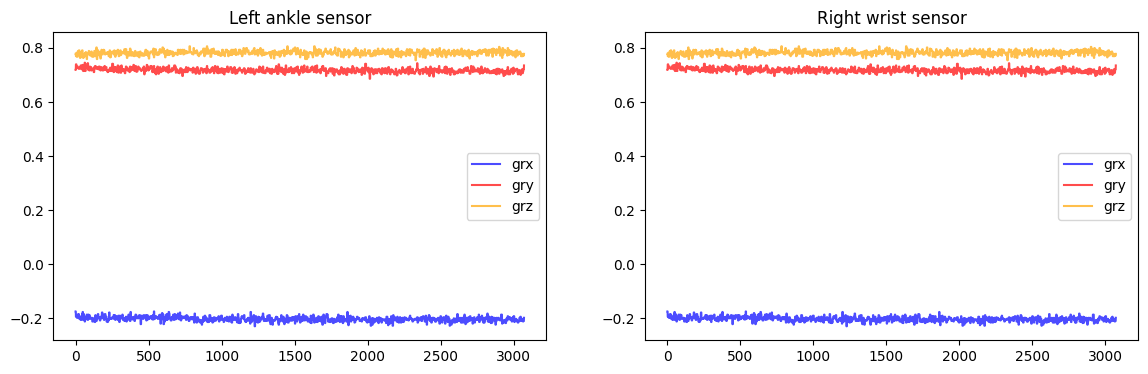

=============================Walking (1 min)-a============================


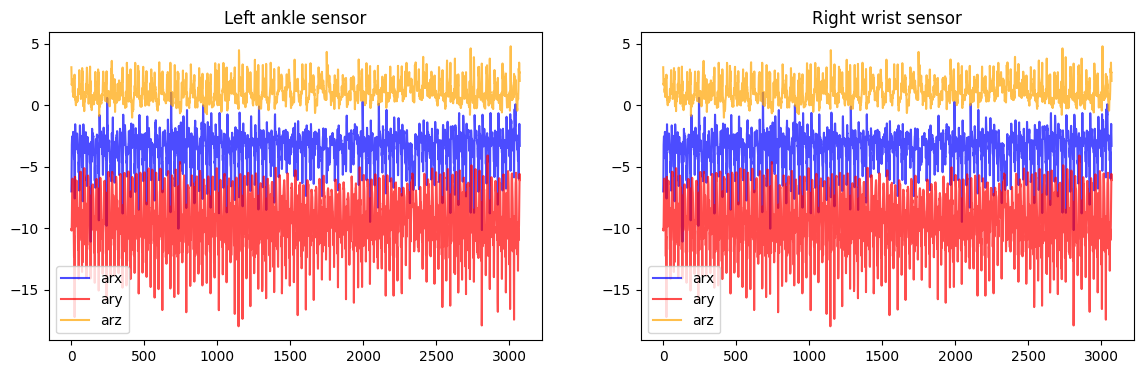

=============================Walking (1 min)-g============================


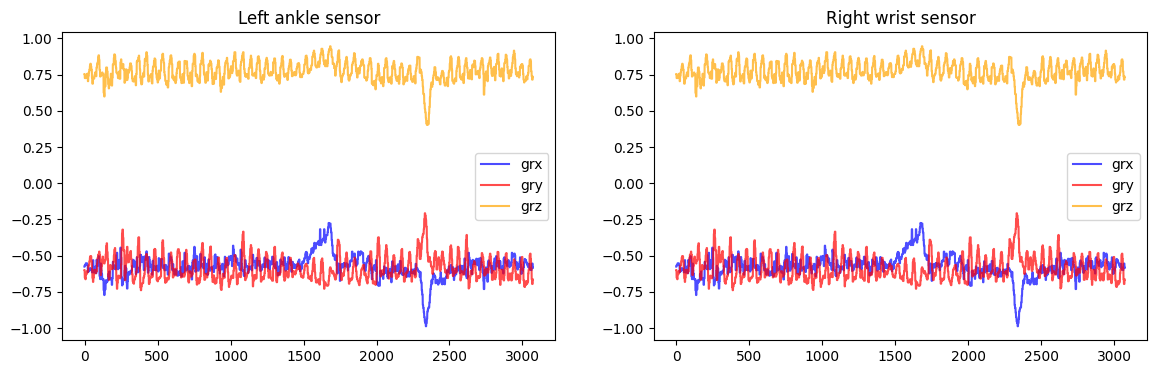

=============================Climbing stairs (1 min)-a============================


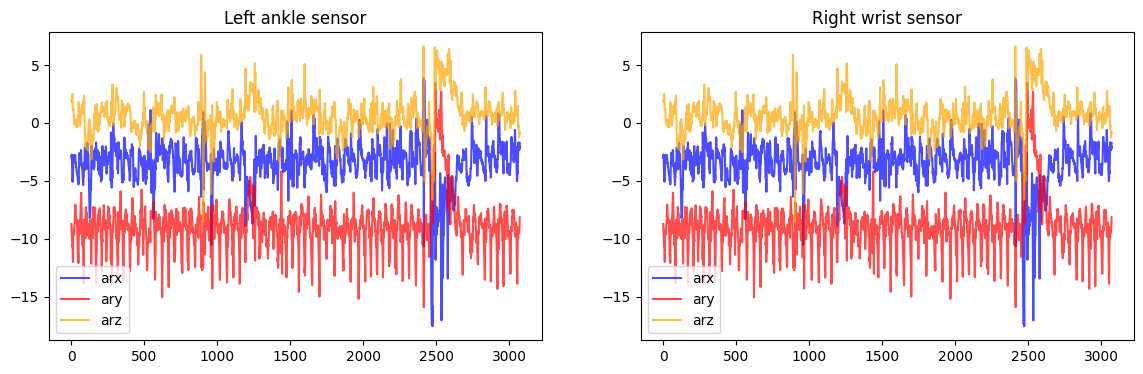

=============================Climbing stairs (1 min)-g============================


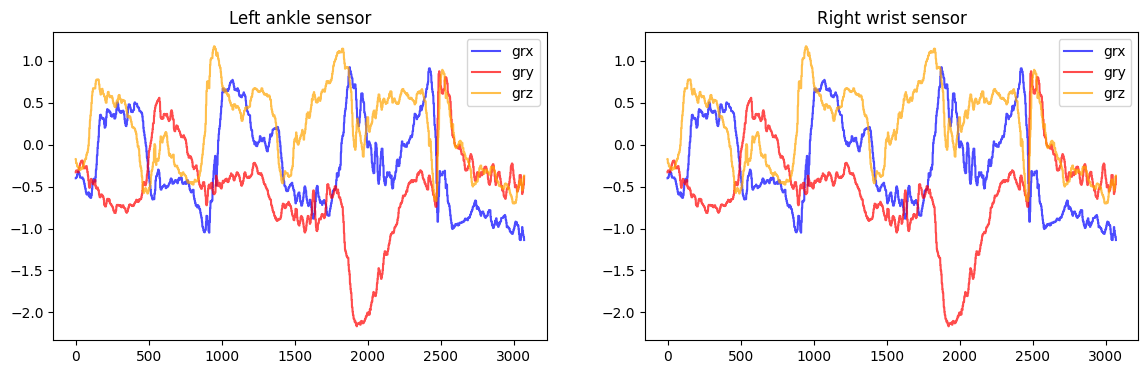

=============================Waist bends forward (20x)-a============================


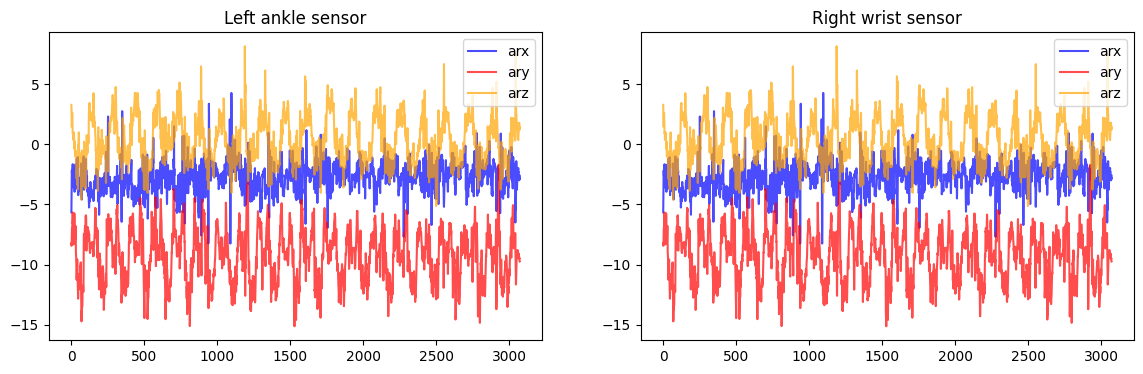

=============================Waist bends forward (20x)-g============================


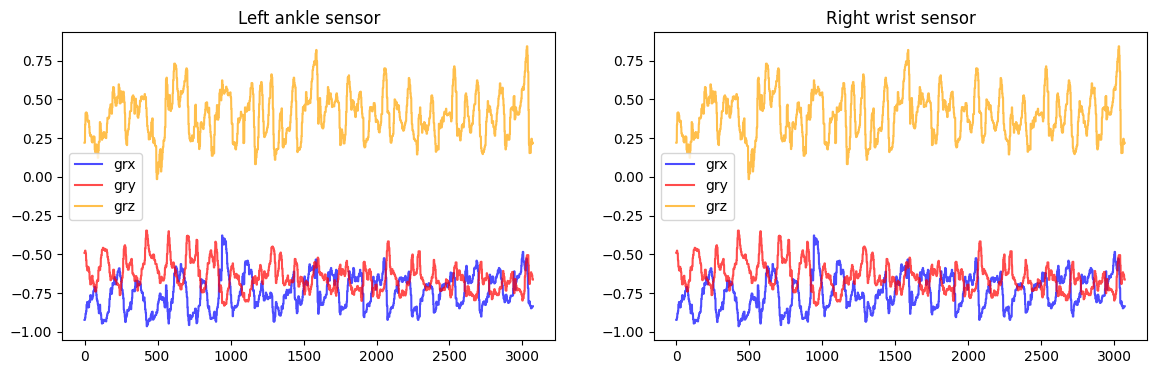

=============================Frontal elevation of arms (20x)-a============================


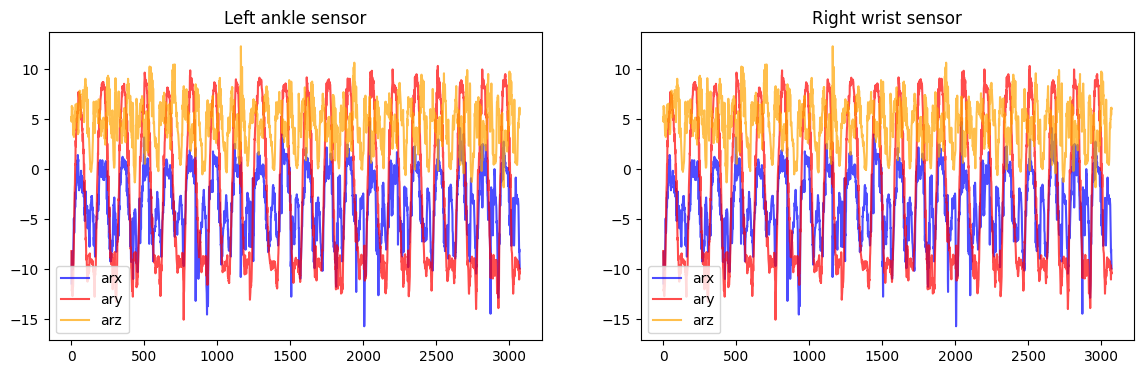

=============================Frontal elevation of arms (20x)-g============================


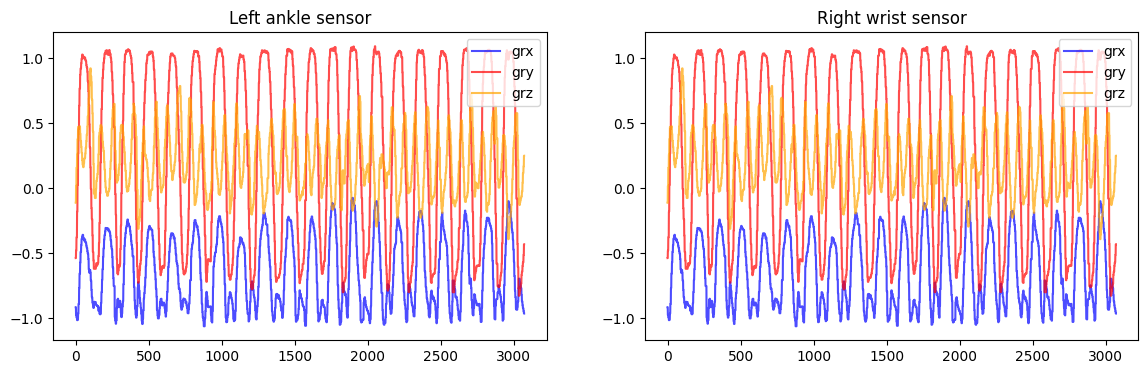

=============================Knees bending (crouching) (20x)-a============================


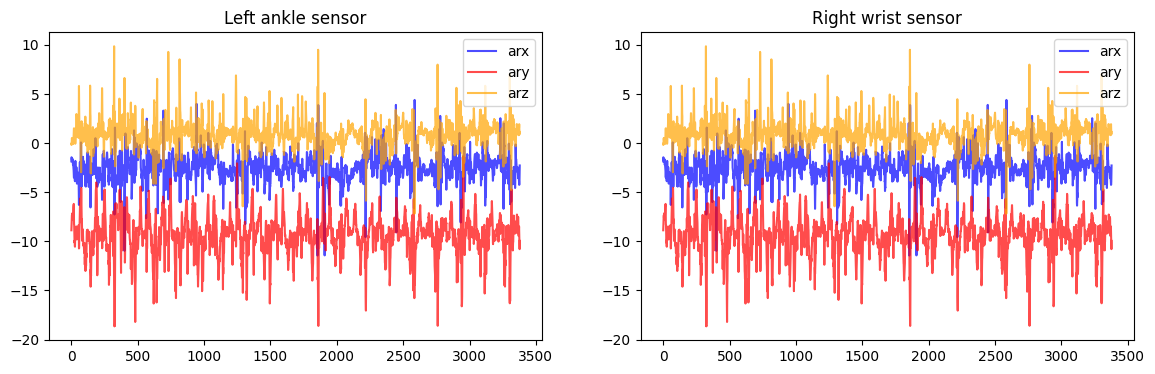

=============================Knees bending (crouching) (20x)-g============================


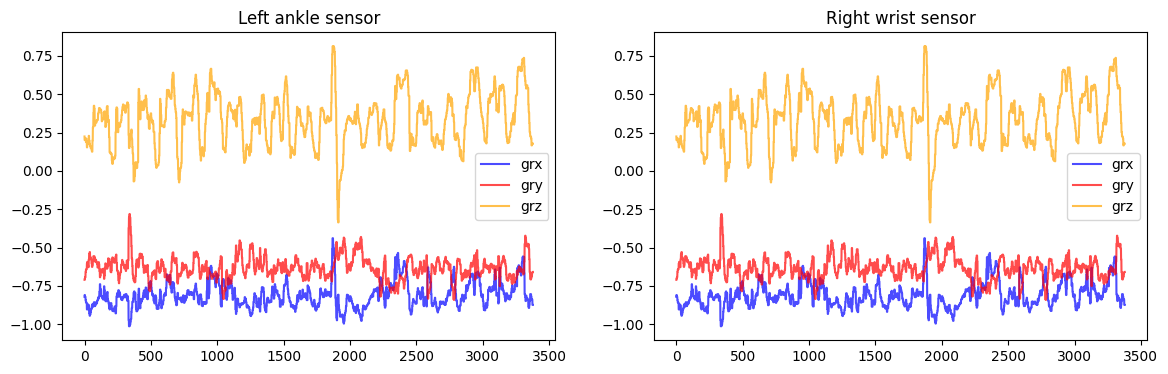

=============================Cycling (1 min)-a============================


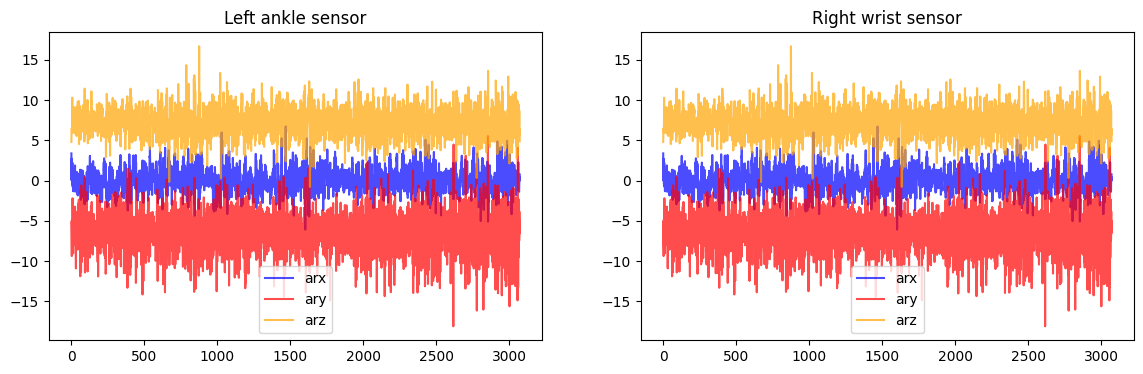

=============================Cycling (1 min)-g============================


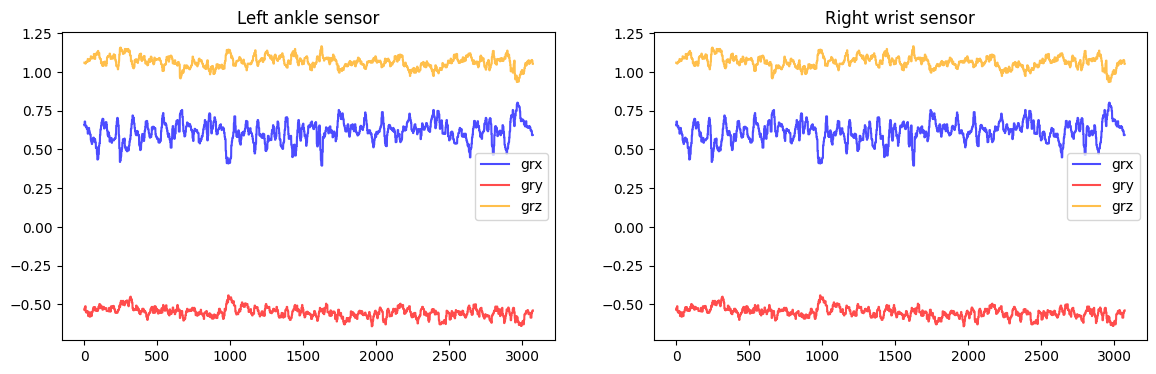

=============================Jogging (1 min)-a============================


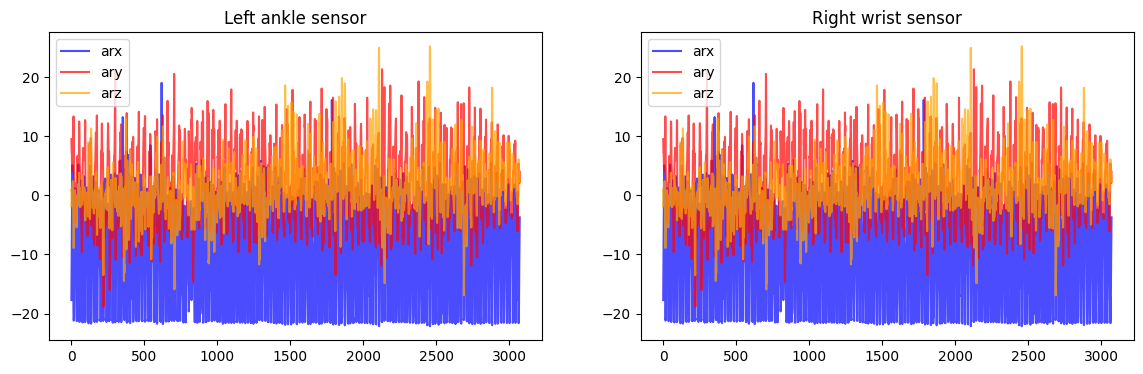

=============================Jogging (1 min)-g============================


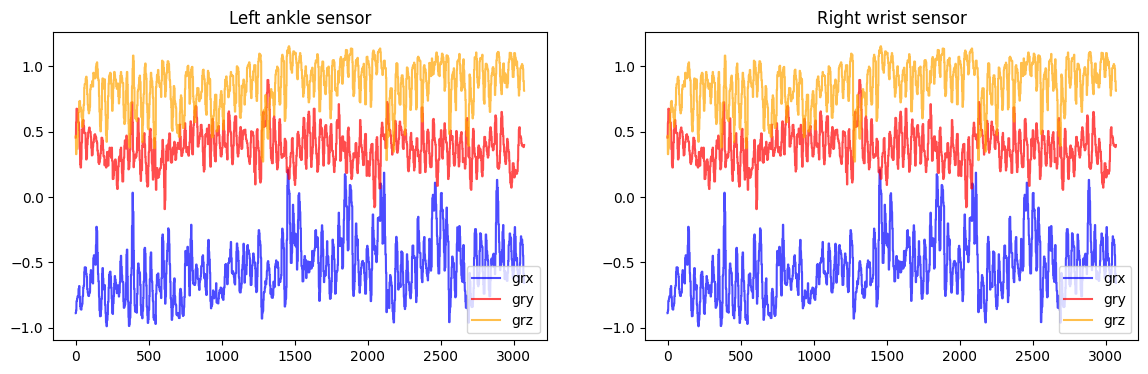

=============================Running (1 min)-a============================


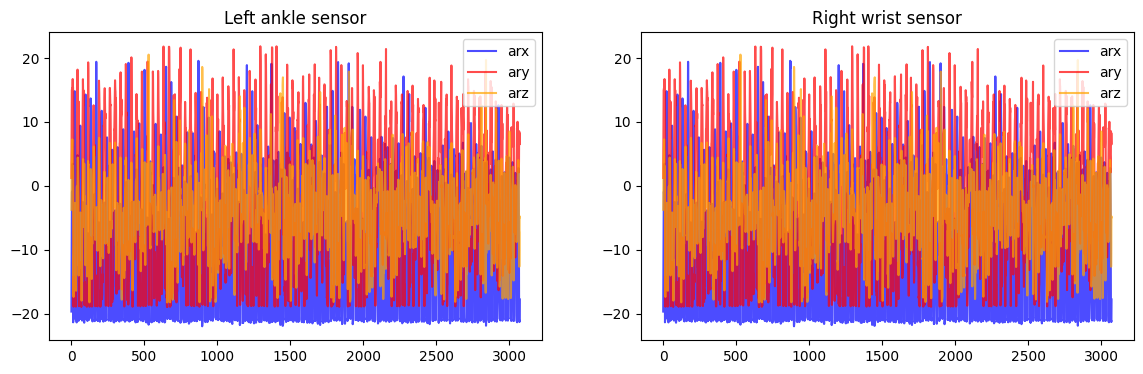

=============================Running (1 min)-g============================


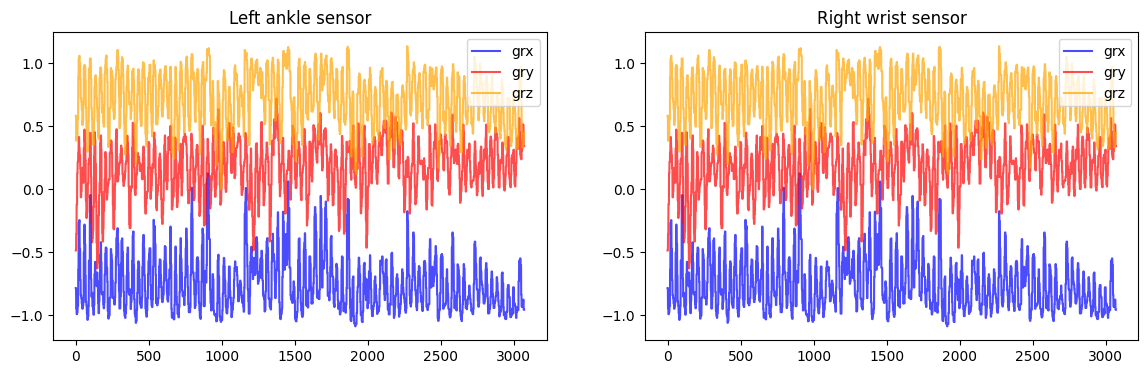

=============================Jump front & back (20x)-a============================


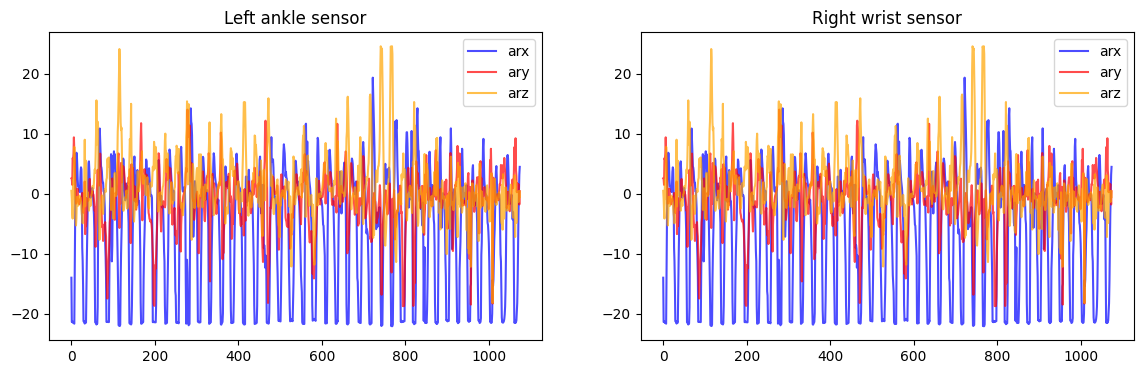

=============================Jump front & back (20x)-g============================


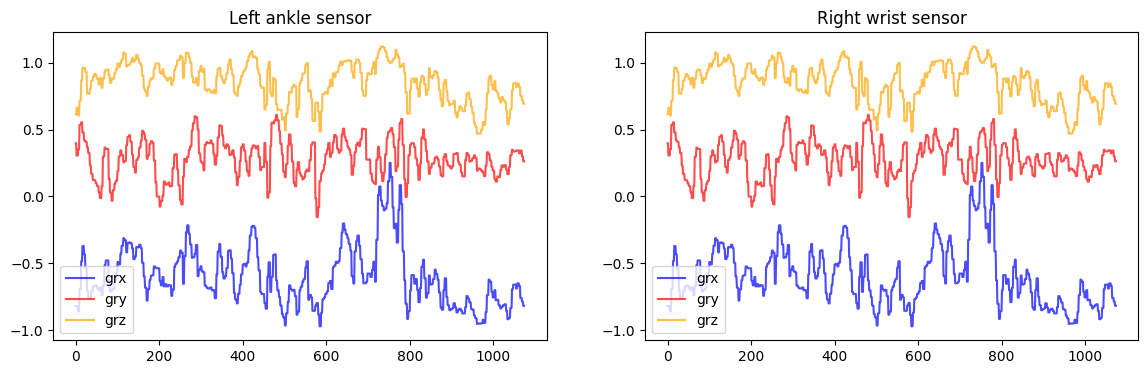

In [58]:
subject1 = df[df['subject']== 'subject1']
readings = ['a','g']

for i in range(1,13):
    for r in readings:
        print(f"============================={activity_label[i]}-{r}============================")
        plt.figure(figsize=(14,4))
        plt.subplot(1,2,1)
        plt.plot(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"rx"],color = 'blue',alpha = 0.7,label = r+"rx")
        plt.plot(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"ry"],color = 'red',alpha = 0.7,label = r+"ry")
        plt.plot(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"rz"],color = 'orange',alpha = 0.7,label = r+"rz")
        plt.title("Left ankle sensor")
        plt.legend()

        plt.subplot(1,2,2)
        plt.plot(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"rx"],color = 'blue',alpha = 0.7,label = r+"rx")
        plt.plot(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"ry"],color = 'red',alpha = 0.7,label = r+"ry")
        plt.plot(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"rz"],color = 'orange',alpha = 0.7,label = r+"rz")
        plt.title("Right wrist sensor")
        plt.legend()
        plt.show()

=============================Standing still (1 min)-a============================


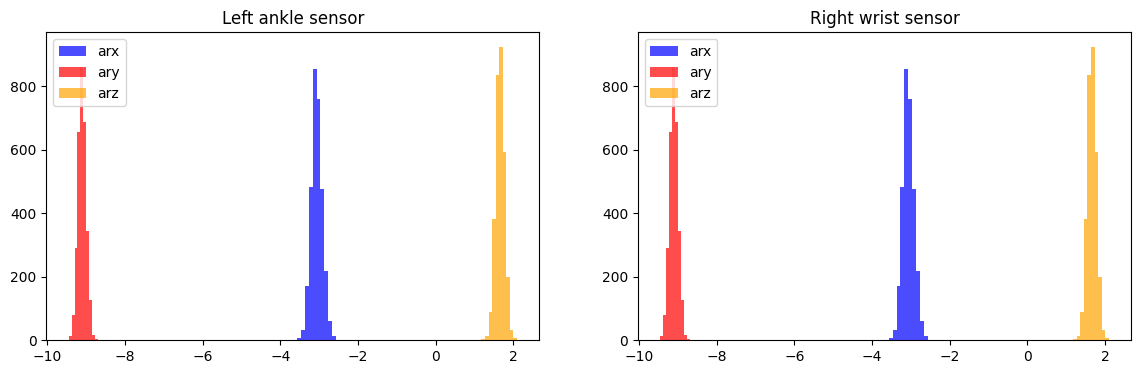

=============================Standing still (1 min)-g============================


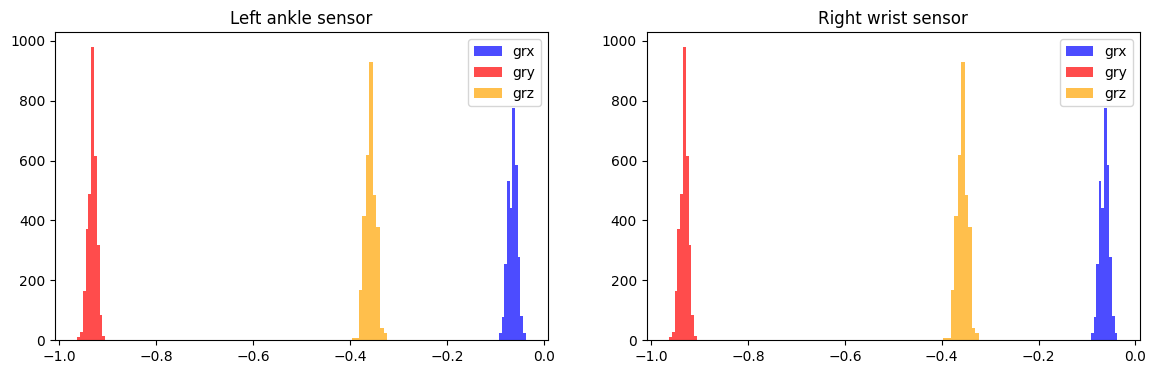

============================= Sitting and relaxing (1 min)-a============================


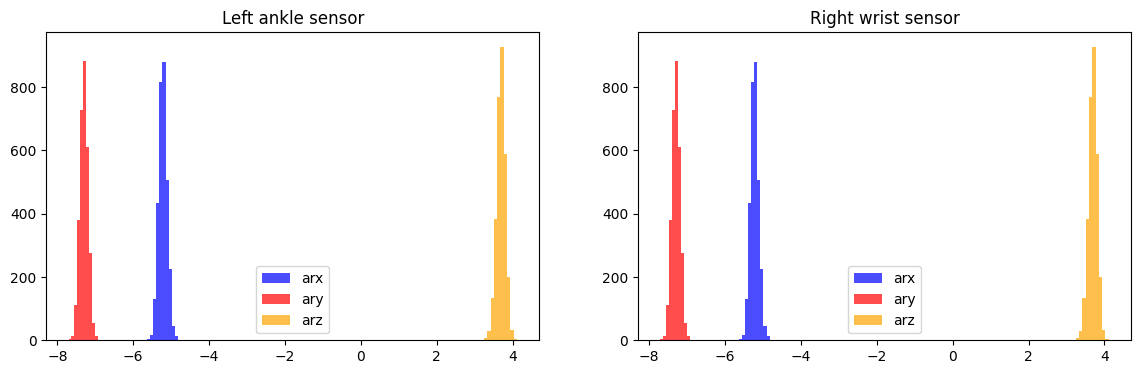

============================= Sitting and relaxing (1 min)-g============================


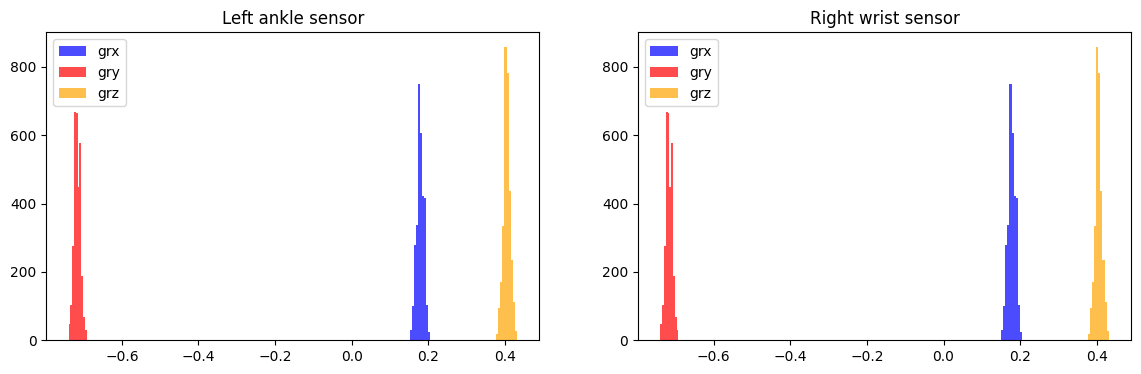

=============================Lying down (1 min)-a============================


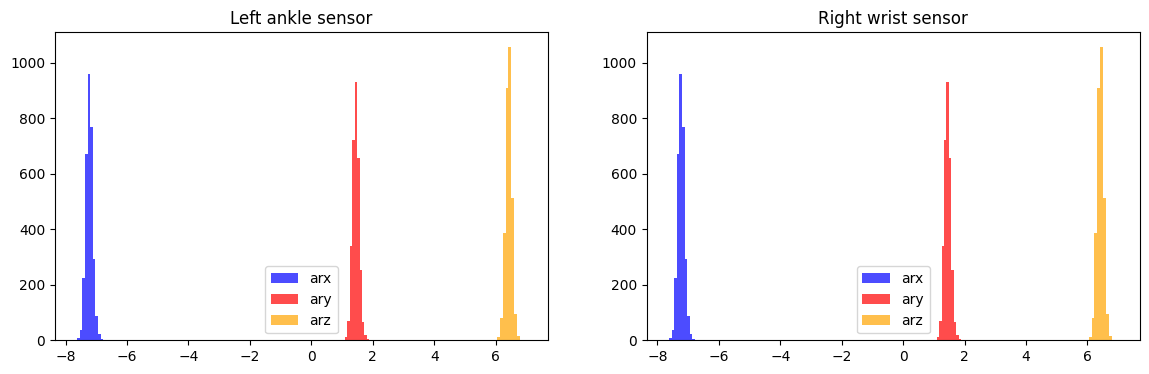

=============================Lying down (1 min)-g============================


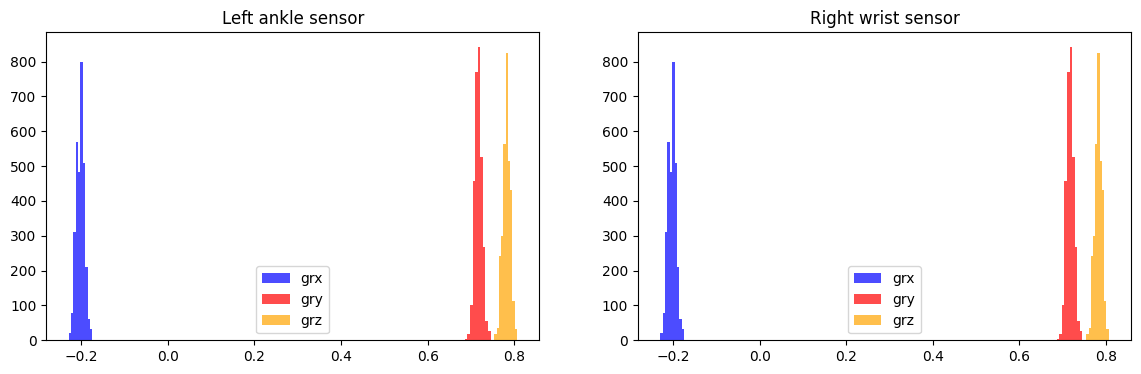

=============================Walking (1 min)-a============================


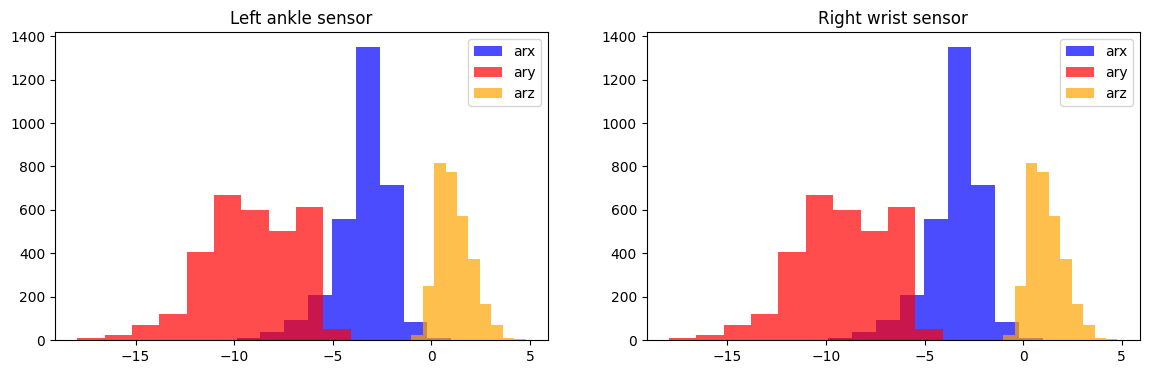

=============================Walking (1 min)-g============================


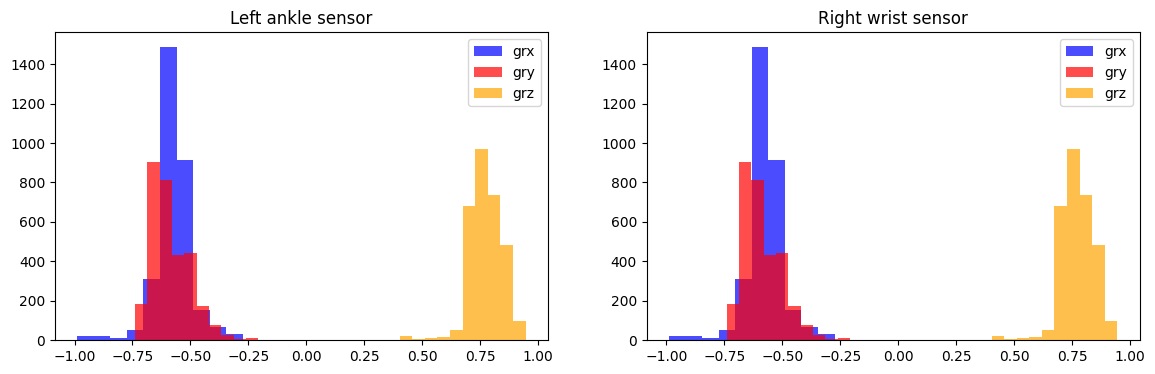

=============================Climbing stairs (1 min)-a============================


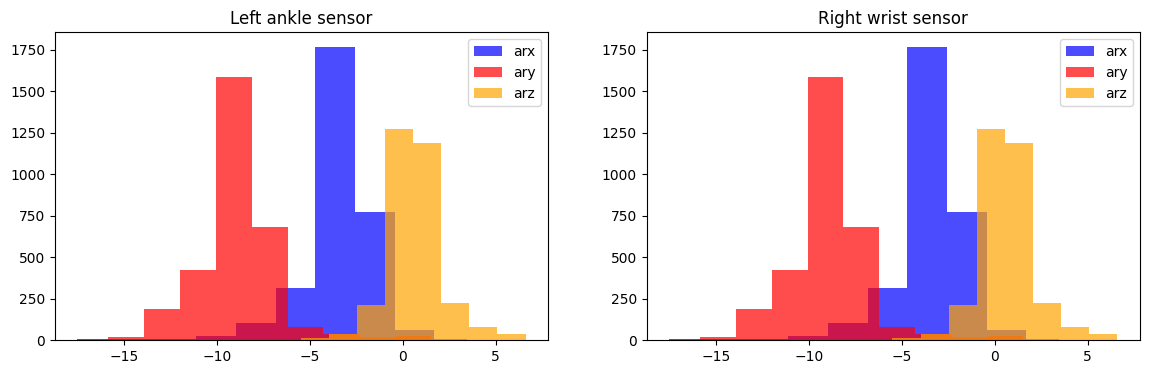

=============================Climbing stairs (1 min)-g============================


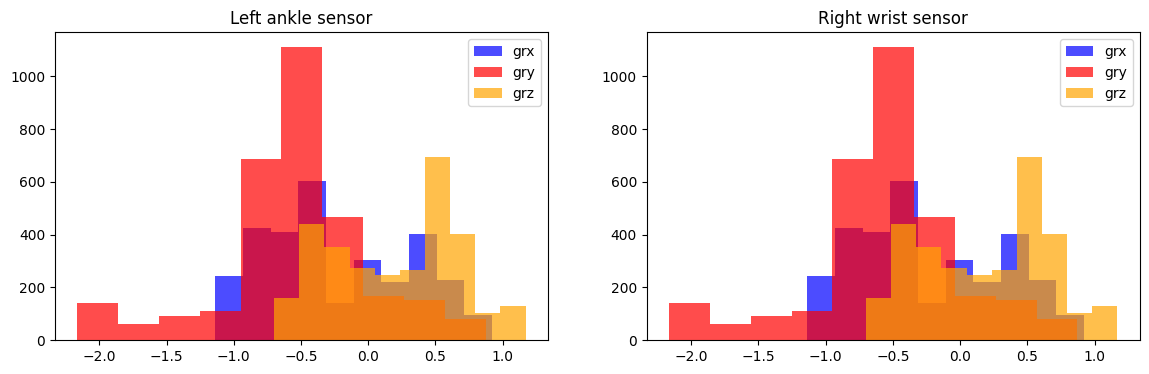

=============================Waist bends forward (20x)-a============================


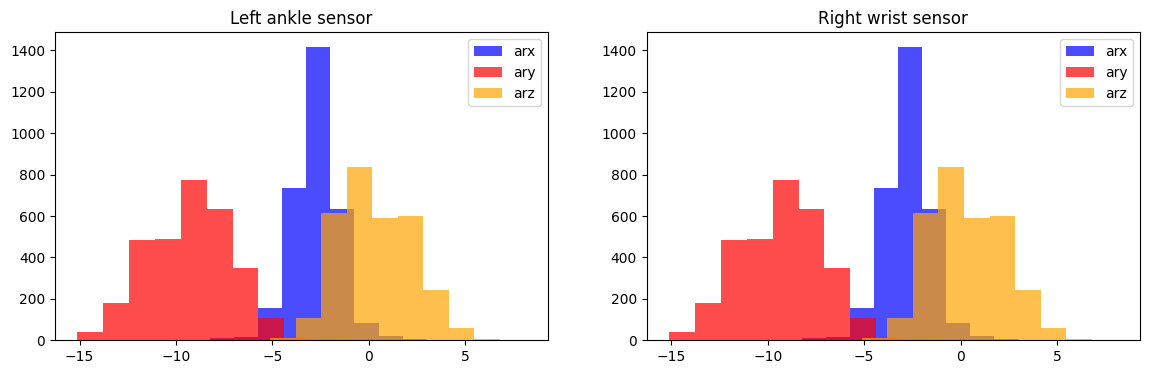

=============================Waist bends forward (20x)-g============================


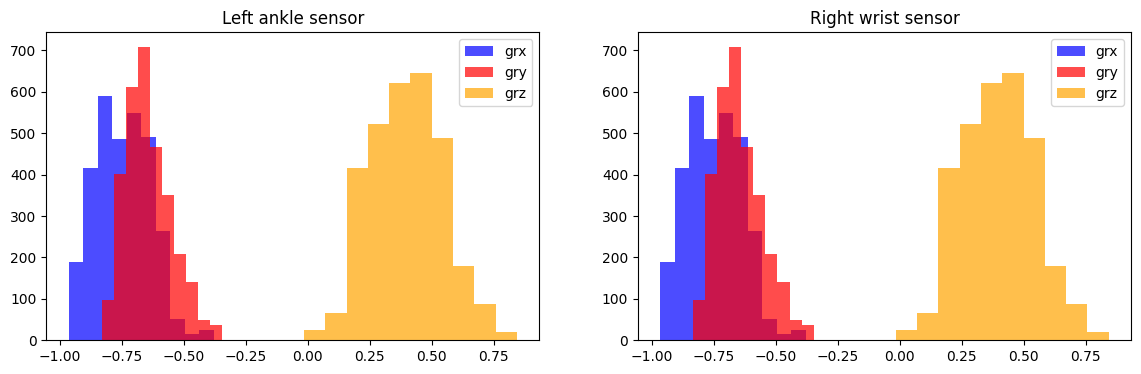

=============================Frontal elevation of arms (20x)-a============================


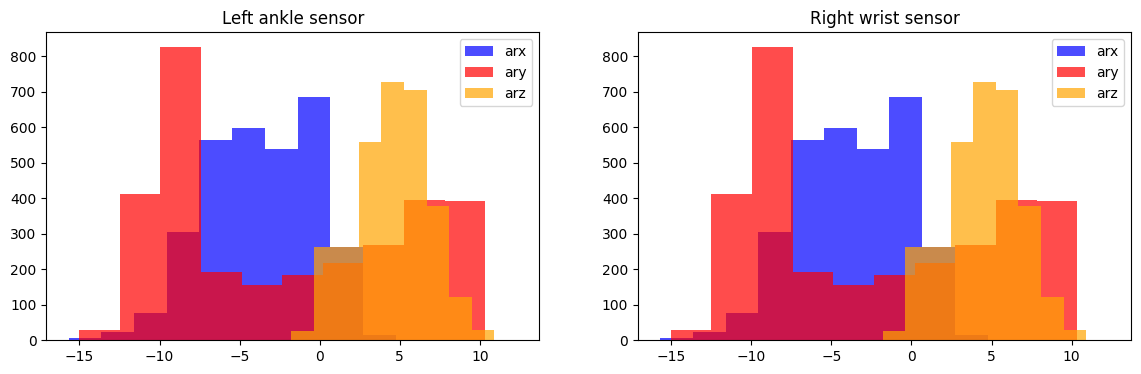

=============================Frontal elevation of arms (20x)-g============================


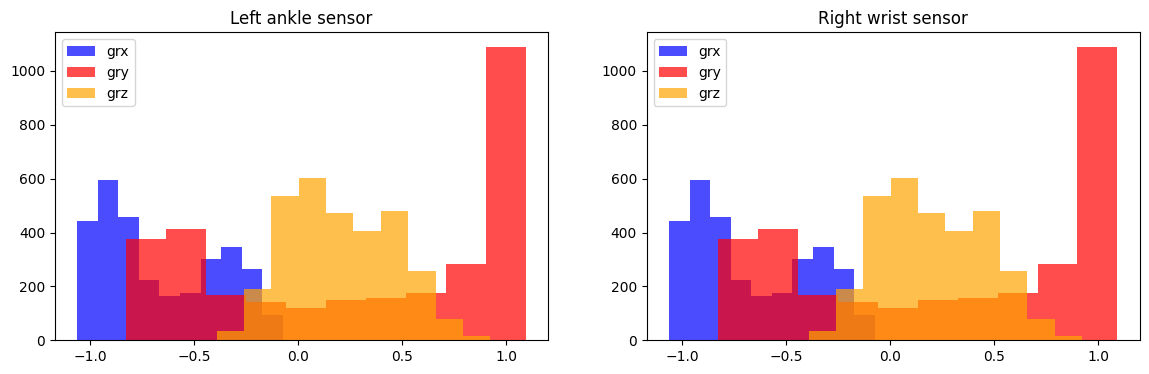

=============================Knees bending (crouching) (20x)-a============================


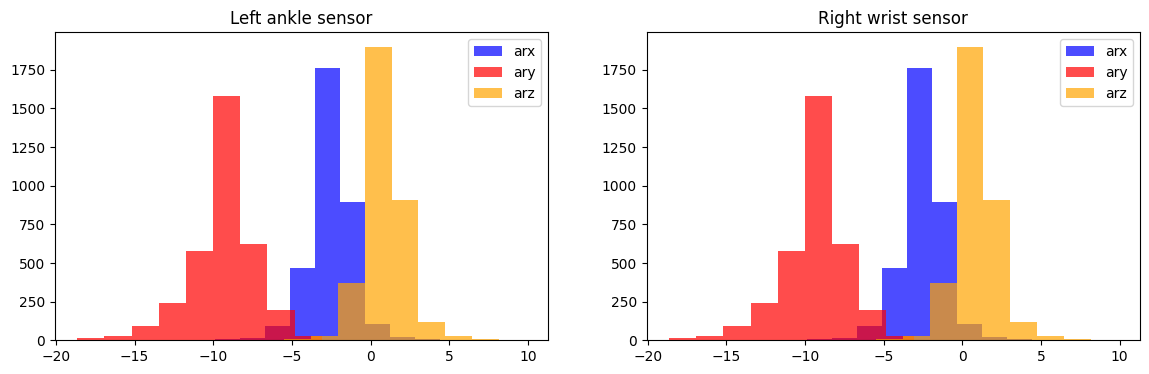

=============================Knees bending (crouching) (20x)-g============================


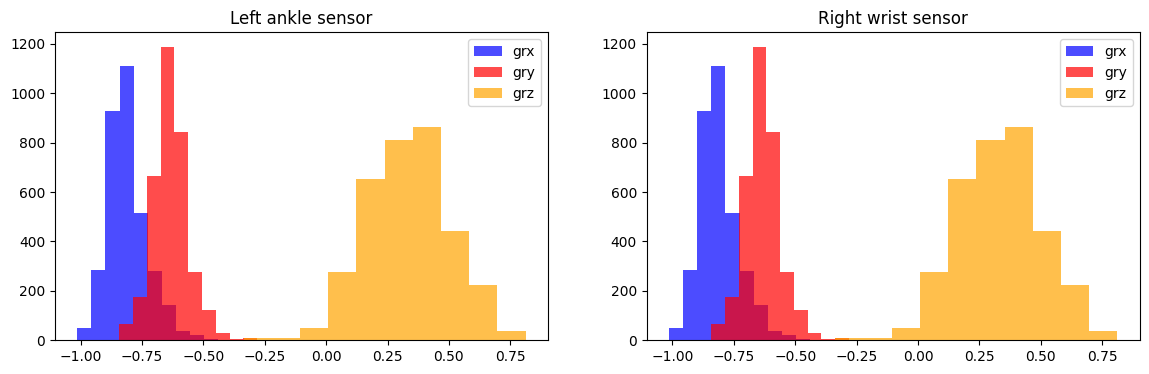

=============================Cycling (1 min)-a============================


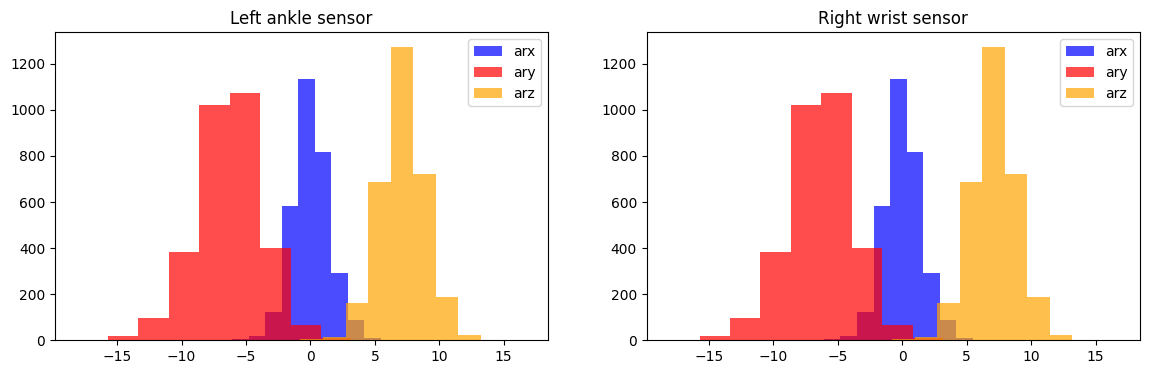

=============================Cycling (1 min)-g============================


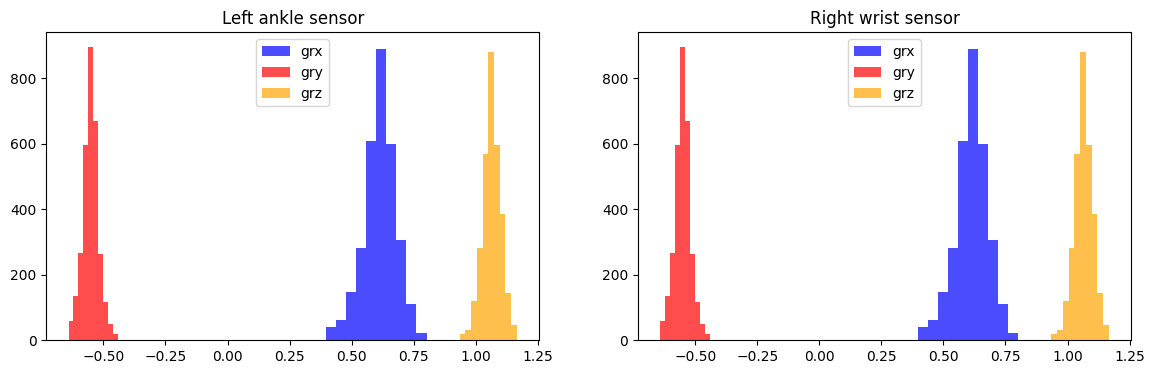

=============================Jogging (1 min)-a============================


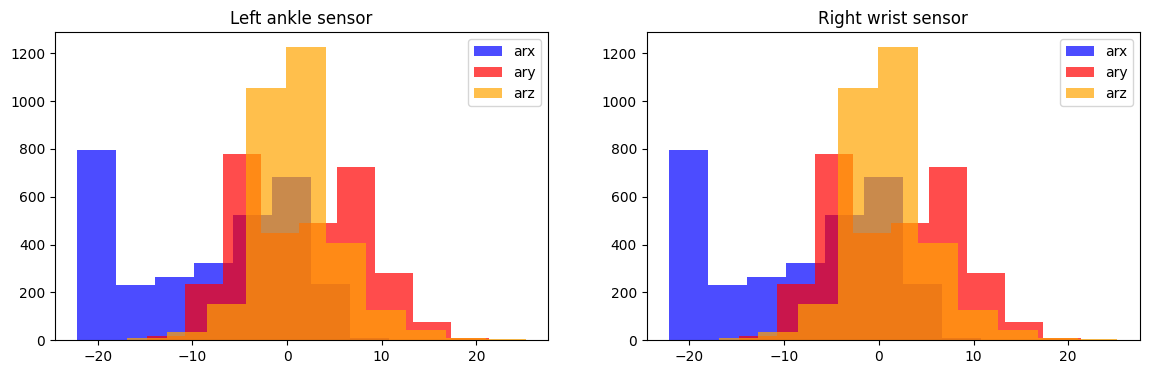

=============================Jogging (1 min)-g============================


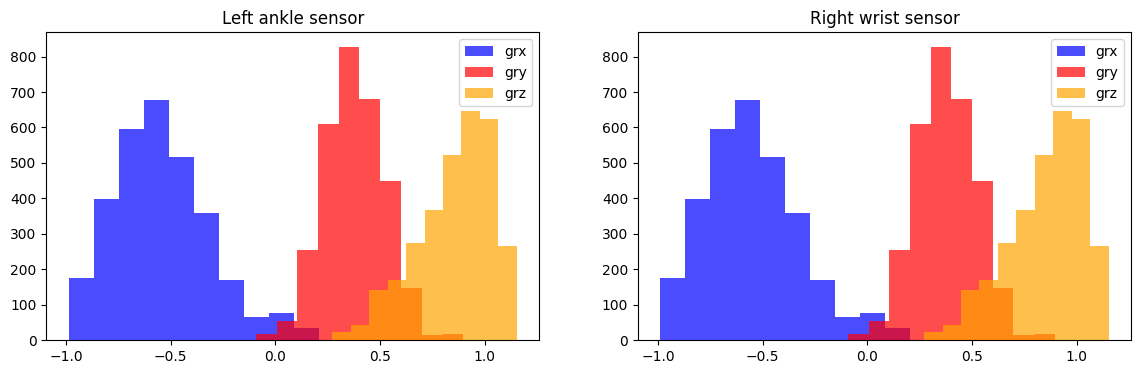

=============================Running (1 min)-a============================


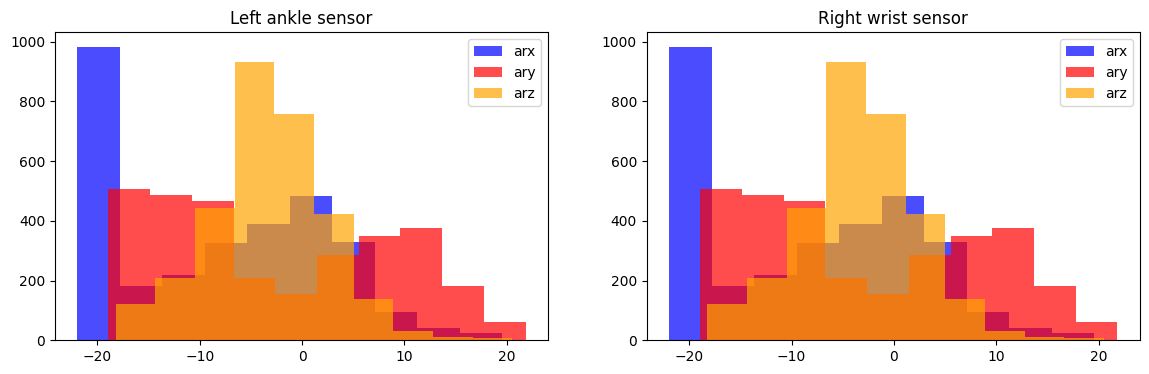

=============================Running (1 min)-g============================


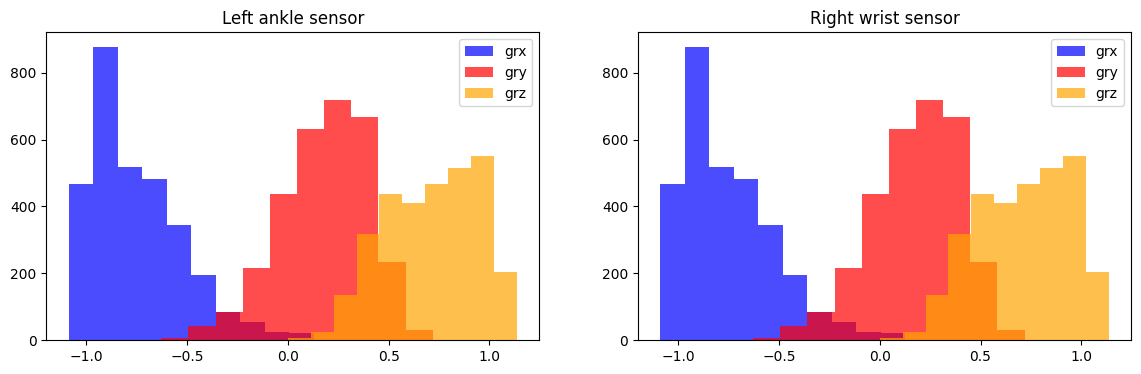

=============================Jump front & back (20x)-a============================


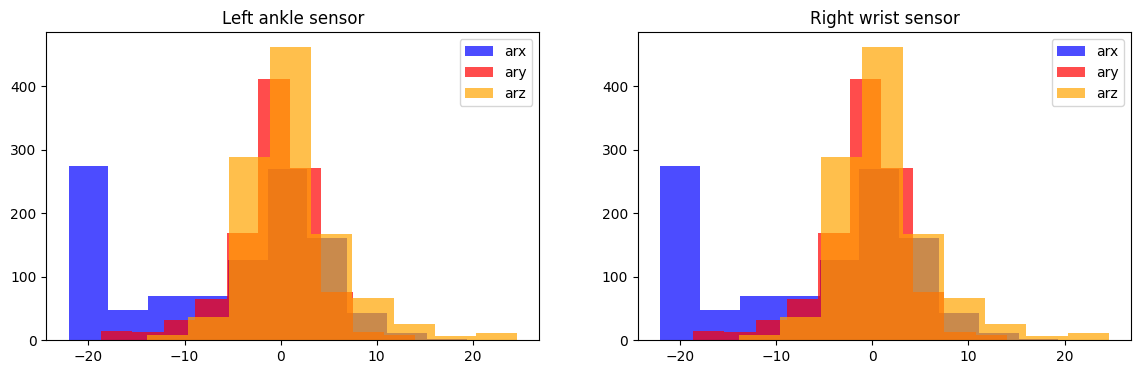

=============================Jump front & back (20x)-g============================


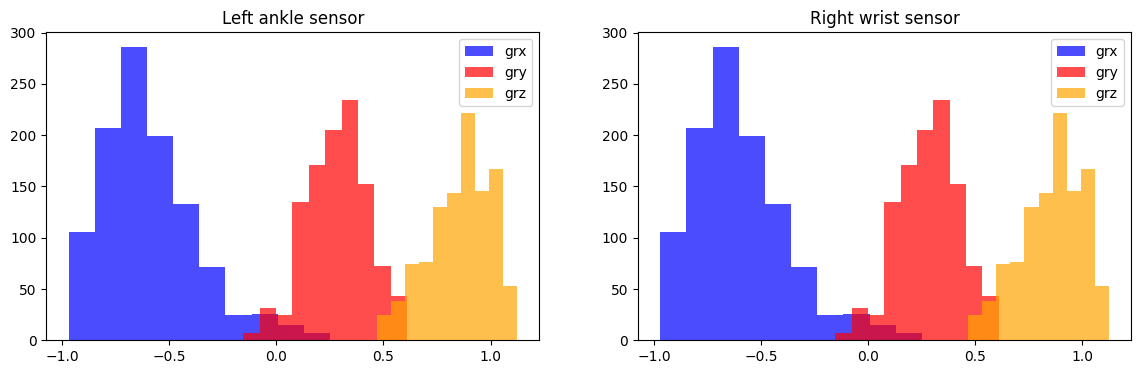

In [59]:
for i in range(1,13):
    for r in readings:
        print(f"============================={activity_label[i]}-{r}============================")
        plt.figure(figsize=(14,4))
        plt.subplot(1,2,1)
        plt.hist(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"rx"],color = 'blue',alpha = 0.7,label = r+"rx")
        plt.hist(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"ry"],color = 'red',alpha = 0.7,label = r+"ry")
        plt.hist(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"rz"],color = 'orange',alpha = 0.7,label = r+"rz")
        plt.title("Left ankle sensor")
        plt.legend()

        plt.subplot(1,2,2)
        plt.hist(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"rx"],color = 'blue',alpha = 0.7,label = r+"rx")
        plt.hist(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"ry"],color = 'red',alpha = 0.7,label = r+"ry")
        plt.hist(subject1[subject1['Activity']== i ].reset_index(drop = True)[r+"rz"],color = 'orange',alpha = 0.7,label = r+"rz")
        plt.title("Right wrist sensor")
        plt.legend()
        plt.show()

In [60]:
df['Activity'] = df['Activity'].replace([0,1,2,3,4,5,6,7,8,9,10,11,12],['None',
                                                                        'Standing still (1 min)',
                                                                        'Sitting and relaxing (1 min)',
                                                                        'Lying down (1 min)',
                                                                        'Walking (1 min)',
                                                                        'Climbing stairs (1 min)',
                                                                        'Waist bends forward (20x)',
                                                                        'Frontal elevation of arms (20x)',
                                                                        'Knees bending (crouching) (20x)',
                                                                        'Cycling (1 min)','Jogging (1 min)',
                                                                        'Running (1 min)','Jump front & back (20x)'])

In [61]:
df["Activity"]

15875                         None
871204                        None
708669                        None
112638                        None
94909                         None
                    ...           
1213641    Jump front & back (20x)
1213642    Jump front & back (20x)
1213643    Jump front & back (20x)
1213644    Jump front & back (20x)
1213645    Jump front & back (20x)
Name: Activity, Length: 383195, dtype: object

In [62]:
df.Activity.value_counts()

Activity
None                               40000
Standing still (1 min)             30720
Sitting and relaxing (1 min)       30720
Lying down (1 min)                 30720
Walking (1 min)                    30720
Cycling (1 min)                    30720
Jogging (1 min)                    30720
Running (1 min)                    30720
Climbing stairs (1 min)            30720
Frontal elevation of arms (20x)    29441
Knees bending (crouching) (20x)    29337
Waist bends forward (20x)          28315
Jump front & back (20x)            10342
Name: count, dtype: int64

<Axes: >

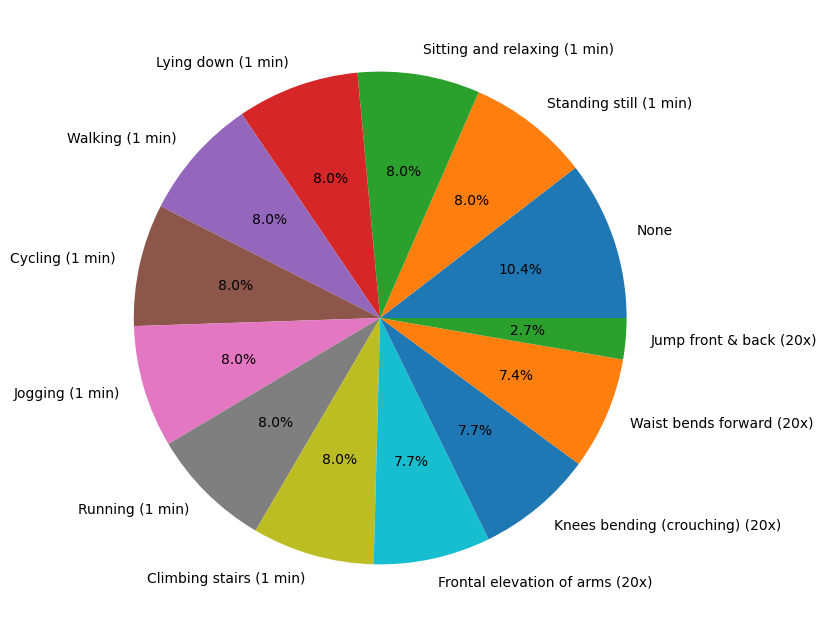

In [65]:
plt.figure(figsize=(12,8))
round (df["Activity"].value_counts()/df.shape[0]*100,2).plot.pie(autopct= '%2.1f%%')